In [8]:
# %cd turnus
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of model failed: Traceback (most recent call last):
  File "/home/dmatis/.local/lib/python3.8/site-packages/IPython/extensions/autoreload.py", line 273, in check
    superreload(m, reload, self.old_objects)
  File "/home/dmatis/.local/lib/python3.8/site-packages/IPython/extensions/autoreload.py", line 471, in superreload
    module = reload(module)
  File "/usr/lib/python3.8/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 604, in _exec
  File "<frozen importlib._bootstrap_external>", line 779, in exec_module
  File "<frozen importlib._bootstrap_external>", line 916, in get_code
  File "<frozen importlib._bootstrap_external>", line 846, in source_to_code
  File "<frozen importlib._bootstrap>", line 219, in _call_with_frames_removed
  File "/home/dmatis/s/ssd/rl-optimization/turnus-multidepo/model.py", line 73
    attention_weights = F.softmax(, dim=0)  # Learn attention weights
                      

In [29]:
from model import HybridNetwork
from env import Env
from utils.problem_loader import ProblemLoader
from torch_geometric.data import Batch

problem_loader = ProblemLoader('data/4dep_10trips/')

env = Env(None, problem_loader.load('RN-4-10-01'))
env2 = Env(None, problem_loader.load('RN-2-3-00'))

batch = Batch.from_data_list([env.graph, env.graph])
net = HybridNetwork(env.state_space(), env.action_space())

net(batch)

(tensor([[-0.0138, -0.0138, -0.0138, -0.0138, -0.0148, -0.0170, -0.0170, -0.0154,
          -0.0153, -0.0154, -0.0162, -0.0171, -0.0172, -0.0172, -0.0188, -0.0188,
          -0.0188, -0.0188],
         [-0.0138, -0.0138, -0.0138, -0.0138, -0.0148, -0.0170, -0.0170, -0.0154,
          -0.0153, -0.0154, -0.0162, -0.0171, -0.0172, -0.0172, -0.0188, -0.0188,
          -0.0188, -0.0188]], grad_fn=<ViewBackward0>),
 tensor([[-0.1191],
         [-0.1191]], grad_fn=<AddmmBackward0>),
 tensor([[-0.1191],
         [-0.1191]]))

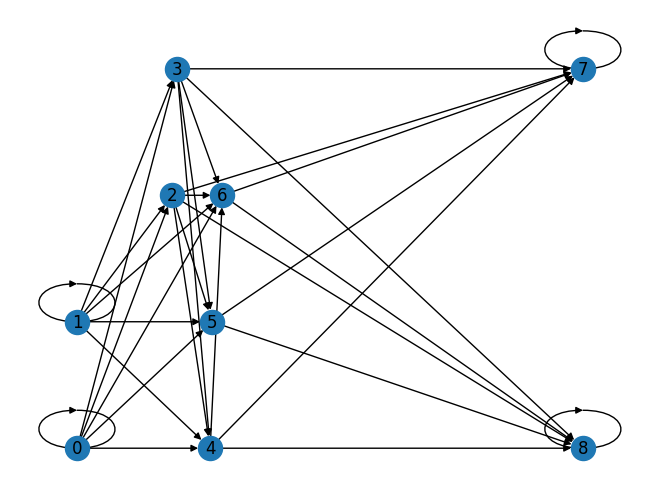

In [3]:
from torch_geometric.utils import to_networkx
from env import Env
import networkx as nx

g = to_networkx(graph)

# g = nx.relabel_nodes(g, lambda i: f'{i}\n{graph.x[i].item()}')

# set initial position of graph nodes based on the timestamp, the higher the timestamp the more to the right
pos = {i: (graph.x[i, 0].item() * 15, i * 10 % 40) for i in range(graph.num_nodes)}
# pos = nx.spring_layout(g)

nx.draw(g, pos, with_labels=True)

In [11]:
import torch
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_networkx
from env import Env
import networkx as nx
import torch_geometric.transforms as T

nodes = torch.Tensor([[1], [2], [3], [4], [5]])
edges = torch.Tensor([[0,1], [0,2], [0,3], [1,2], [1,3], [2,4], [3,4]]).to(torch.long).contiguous().t()
data = Data(x=nodes, edge_index=edges)
addOne = T.OneHotDegree(max_degree=4)
data = addOne(data)

# g = to_networkx(data, to_undirected=True)

# g = nx.relabel_nodes(g, lambda i: f'{i}\n{data.x[i].item()}')

# pos = nx.spring_layout(g, seed=46)
# nx.draw(g, pos, with_labels=True)

data

Data(x=[5, 6], edge_index=[2, 7])

In [32]:
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx
import networkx as nx
from env import Env
import torch

torch.set_printoptions(precision=3)


env = Env(None, graph)

def p(tpl):
    global env
    g, mask, reward, terminal, _ = tpl
    print(g.x, "\n", mask, reward, terminal, env.choosing_morning_depot)
    # draw(g)

def draw(graph):
    g = to_networkx(graph, to_undirected=True)

    # g = nx.relabel_nodes(g, lambda i: f'{i}\n{graph.x[i, env.flag_current_node_index].item()}\n{int(graph.x[i, env.flag_visited_index].item() * env.MAX_VEHICLES)}')

    pos = nx.spring_layout(g, seed=46)
    nx.draw(g, pos, with_labels=True)
    plt.show()

p(env.step(1))
p(env.step(2))
p(env.step(3))
p(env.step(4))
p(env.step(5))
p(env.step(8))
p(env.step(0))
p(env.step(6))
p(env.step(7))

tensor([[0.000, 0.000, 0.000, 1.000, 1.000, 1.000, 0.000, 0.000, 1.000, 0.000],
        [0.000, 0.000, 0.000, 1.000, 1.000, 1.000, 0.000, 1.000, 0.000, 0.000],
        [0.188, 0.206, 1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 1.000],
        [0.198, 0.216, 1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 1.000],
        [0.263, 0.281, 1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 1.000],
        [0.267, 0.283, 0.897, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 1.000],
        [0.287, 0.300, 0.690, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 1.000],
        [1.000, 1.000, 0.000, 0.000, 1.000, 0.000, 0.000, 0.000, 0.000, 0.000],
        [1.000, 1.000, 0.000, 0.000, 1.000, 0.000, 0.000, 0.000, 0.000, 0.000]]) 
 tensor([False, False,  True,  True,  True,  True,  True, False, False]) 0 False False
tensor([[0.000, 0.000, 0.000, 1.000, 1.000, 1.000, 0.000, 0.000, 1.000, 0.000],
        [0.000, 0.000, 0.000, 1.000, 1.000, 1.000, 0.000, 0.000, 0.000, 0.000],
        [0.188, 0.206, 1.000, 0